# Proyecto final integrador · Fase 4
## Nacimientos en Chile, 2020–2023 · Grupo 2

**Equipo:** Cristian Hurtado Cabezas, Jorge Altamirano Navarrete, Renzo Vílchez y Luis Paredes.

Este cuaderno consolida el recorrido F1–F4 del proyecto. F1 definió tres preguntas descriptivas; F2 produjo un conjunto preparado y dejó documentada la mediana regional para las tallas ausentes; F3 verificó un núcleo modular, una clase de análisis, estrategias intercambiables y mediciones de eficiencia. F4 usa esos resultados para responder las preguntas con tablas, figuras y una discusión de sus límites. El [ejemplo docente de Semana 3](https://github.com/magistercienciadatos/Material_Didactico_Semana3/blob/main/proyecto-grupoX-mcdi500/F4/F4_Consolidado_Proyecto.ipynb) orienta la estructura; las preguntas y los datos aquí son propios del Grupo 2.

**Orden de ejecución:** con el kernel de `requirements.txt`, ejecutar F1 y F2 cuando se parte del CSV original; después ejecutar F3 y, finalmente, este cuaderno con **Restart & Run All**. Este cuaderno necesita la salida de F2 en `data/processed/nacimientos_preparados_propuesta.csv`. Los CSV grandes son locales y no se suben a GitHub.

## 0. Entorno y rutas

La primera celda comprueba el intérprete y las versiones fijadas. Se detiene antes de generar figuras si se eligió otro kernel. Las rutas se resuelven desde la raíz del repositorio.

In [1]:
from pathlib import Path
from importlib import metadata
import hashlib
import json
import sys

def encontrar_raiz():
    for carpeta in (Path.cwd(), *Path.cwd().parents):
        if (carpeta / "requirements.txt").is_file() and (carpeta / "F2/F2_Preparacion.ipynb").is_file():
            return carpeta
    raise FileNotFoundError("Abra la carpeta raíz del proyecto en VS Code y ejecute desde allí.")

RAIZ = encontrar_raiz()
esperadas = {}
for linea in (RAIZ / "requirements.txt").read_text(encoding="utf-8").splitlines():
    if "==" in linea and not linea.lstrip().startswith("#"):
        nombre, version = linea.split("==", 1)
        esperadas[nombre.strip()] = version.strip()
diferencias = {}
for nombre, esperada in esperadas.items():
    try:
        actual = metadata.version(nombre)
    except metadata.PackageNotFoundError:
        actual = "no instalado"
    if actual != esperada:
        diferencias[nombre] = f"{actual} (se requiere {esperada})"
if diferencias:
    raise RuntimeError(
        f"El kernel no coincide con requirements.txt: {diferencias}. "
        f"Intérprete: {sys.executable}. Seleccione el Python de .venv y reinicie el notebook."
    )
print("Raíz:", RAIZ)
print("Python:", sys.version.split()[0], "|", sys.executable)
print("Dependencias fijadas verificadas:", esperadas)

Raíz: D:\Magister UNAB\Curso 01\C01Week01\Evaluaciones\proyecto-grupo2
Python: 3.13.5 | D:\Magister UNAB\Curso 01\C01Week01\Evaluaciones\proyecto-grupo2-f3-cristian\.venv\Scripts\python.exe
Dependencias fijadas verificadas: {'ipykernel': '7.3.0', 'jupyterlab': '4.6.4', 'matplotlib': '3.11.1', 'notebook': '7.6.3', 'numpy': '2.5.2', 'pandas': '3.0.5', 'scikit-learn': '1.9.0', 'scipy': '1.18.1'}


## I. F1 · Problema, objetivos y límites

Cada fila del archivo representa **un nacido vivo registrado**, no necesariamente una madre o un parto distinto. Las preguntas son descriptivas y se refieren a 2020–2023:

1. ¿Qué regiones de residencia materna tienen el mayor y el menor **porcentaje de nacidos vivos de madres menores de 20 años**?
2. ¿Qué meses del calendario tienen el mayor y el menor **promedio diario de nacimientos**?
3. ¿Qué regiones de residencia materna tienen la mayor y la menor **talla media al nacer**, en centímetros?

Supuestos operativos: los códigos regionales y los meses del conjunto preparado corresponden al catálogo declarado en F2; `madre_menor_20` proviene de las categorías de edad materna; los días de cada mes son calendario. **No existe una fecha diaria por nacimiento en esta fuente preparada**. El estudio no estima embarazos, causas ni efectos de la pandemia. El período 2020–2023 no incluye una línea base anterior a ella.

## II. F2 · Entrada preparada y validación

Se cargan solo las columnas necesarias. Las glosas regionales y los centímetros se conservan para tablas y figuras; la codificación one-hot de F3 no reemplaza esta versión interpretable. La talla principal usa la **mediana regional acordada** cuando falta el dato; más adelante se contrasta con las tallas observadas.

In [2]:
import calendar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

PREPARADO = RAIZ / "data/processed/nacimientos_preparados_propuesta.csv"
RAW = RAIZ / "data/raw/Serie_Nacimientos_2020_2023.csv"
META_F2 = RAIZ / "docs/f2/metadatos.json"
META_F3 = RAIZ / "F3/resultados/sumativa2_verificacion.json"
MEDICIONES_F3 = RAIZ / "F3/resultados/mediciones.json"
FIGURAS = RAIZ / "F4/figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)

if not PREPARADO.is_file():
    raise FileNotFoundError(
        f"Falta {PREPARADO}. Coloque el CSV original en data/raw y ejecute F2 completo."
    )
columnas = [
    "ANO_NAC", "MES_NAC", "REGION_RESIDENCIA", "GLOSA_REGION_RESIDENCIA",
    "madre_menor_20", "talla_observada_cm", "talla_analisis_cm", "talla_imputada",
]
datos = pd.read_csv(PREPARADO, usecols=columnas)
meta_f2 = json.loads(META_F2.read_text(encoding="utf-8"))
meta_f3 = json.loads(META_F3.read_text(encoding="utf-8"))
mediciones_f3 = json.loads(MEDICIONES_F3.read_text(encoding="utf-8"))

assert len(datos) == meta_f2["fuente"]["filas"] == meta_f3["entrada"]["filas"]
assert set(datos.ANO_NAC) == {2020, 2021, 2022, 2023}
assert set(datos.MES_NAC) == set(range(1, 13))
assert datos.REGION_RESIDENCIA.nunique() == 16
assert datos.groupby("REGION_RESIDENCIA").GLOSA_REGION_RESIDENCIA.nunique().eq(1).all()
assert pd.api.types.is_bool_dtype(datos.madre_menor_20)
assert pd.api.types.is_bool_dtype(datos.talla_imputada)
assert datos[columnas].notna().all().drop("talla_observada_cm").all()
assert datos.talla_imputada.sum() == meta_f3["entrada"]["tallas_ausentes"] == 597
observadas = datos.talla_observada_cm.notna()
assert np.allclose(datos.loc[observadas, "talla_analisis_cm"],
                   datos.loc[observadas, "talla_observada_cm"])

if RAW.is_file():
    sha = hashlib.sha256()
    with RAW.open("rb") as archivo:
        for bloque in iter(lambda: archivo.read(1024 * 1024), b""):
            sha.update(bloque)
    assert sha.hexdigest() == meta_f2["fuente"]["sha256"]
    print("Huella SHA-256 del original: coincide con F2.")
else:
    print("CSV original no disponible localmente; se verificó la salida preparada y sus metadatos.")
display(pd.DataFrame({
    "control": ["Nacidos vivos", "Regiones", "Meses", "Tallas observadas", "Tallas imputadas"],
    "resultado": [len(datos), datos.REGION_RESIDENCIA.nunique(), 48,
                  int(observadas.sum()), int(datos.talla_imputada.sum())],
}))

Huella SHA-256 del original: coincide con F2.


,control,resultado
0,Nacidos vivos,735611
1,Regiones,16
2,Meses,48
3,Tallas observadas,735014
4,Tallas imputadas,597


## III. F3 · Reutilización del núcleo y evidencia de eficiencia

La clase existente `AnalizadorNacimientos` reproduce el indicador regional. La estrategia orientada a objetos `MedianaRegional` reproduce la talla preparada por F2. Estas comprobaciones conectan los artefactos de fases anteriores con F4, sin copiar sus implementaciones. La tabla de tiempos recupera la **medición realizada en F3**; no atribuye esos tiempos a la ejecución actual.

In [3]:
sys.path.insert(0, str(RAIZ / "F3/src"))
from f3_algoritmos import AnalizadorNacimientos
from f3_estrategias_talla import MedianaRegional

analizador = AnalizadorNacimientos(PREPARADO)
analizador.cargar_preparado()
indicador_f3 = analizador.proporcion_groupby()
control = (
    datos.groupby("REGION_RESIDENCIA", observed=True)["madre_menor_20"]
    .agg(nacimientos="size", madres_menores_20="sum").reset_index()
)
control["porcentaje"] = 100 * control.madres_menores_20 / control.nacimientos
pd.testing.assert_frame_equal(indicador_f3, control)

estrategia = MedianaRegional().ajustar(
    datos[["REGION_RESIDENCIA", "talla_observada_cm"]]
)
talla_reconstruida = estrategia.transformar(
    datos[["REGION_RESIDENCIA", "talla_observada_cm"]]
)
assert np.allclose(talla_reconstruida, datos.talla_analisis_cm, equal_nan=True)
assert mediciones_f3["indicador"]["equivalencia"]
assert mediciones_f3["lectura"]["equivalencia"]
display(pd.DataFrame([
    {"comparación F3": "bucle", "tiempo registrado (s)": mediciones_f3["indicador"]["bucle_s"]},
    {"comparación F3": "groupby", "tiempo registrado (s)": mediciones_f3["indicador"]["groupby_s"]},
    {"comparación F3": "lectura completa", "tiempo registrado (s)": mediciones_f3["lectura"]["completa_s"]},
    {"comparación F3": "lectura selectiva", "tiempo registrado (s)": mediciones_f3["lectura"]["selectiva_s"]},
]))
print("Clase, estrategia y salida preparada: resultados equivalentes.")
print("Memoria de DataFrame en F3:",
      round(mediciones_f3["lectura"]["completa_mb"], 1), "MB completa frente a",
      round(mediciones_f3["lectura"]["selectiva_mb"], 1), "MB selectiva.")

,comparación F3,tiempo registrado (s)
0,bucle,0.142276
1,groupby,0.008969
2,lectura completa,0.970971
3,lectura selectiva,0.544984


Clase, estrategia y salida preparada: resultados equivalentes.
Memoria de DataFrame en F3: 408.1 MB completa frente a 127.3 MB selectiva.


El criterio de optimización permanece: `groupby` evita el recorrido Python sobre cada fila y la lectura selectiva reduce el uso de memoria del DataFrame. La memoria rastreada por `tracemalloc` en F3 se interpreta como asignaciones observadas por esa herramienta, **no** como toda la memoria del proceso.

## IV. F4 · Indicador regional de madres menores de 20 años

Para cada región, el denominador es **todos los nacidos vivos registrados en esa región**, no el número de mujeres residentes. El intervalo de Wilson al 95 % cuantifica la incertidumbre de una proporción bajo un modelo binomial; el porcentaje observado del período se conoce exactamente para este conjunto. Se presenta el tamaño de cada grupo para evitar interpretar solo el ranking.

In [4]:
def intervalo_wilson(exitos, total, confianza=0.95):
    exitos = np.asarray(exitos, dtype=float)
    total = np.asarray(total, dtype=float)
    if np.any(total <= 0):
        raise ValueError("Los denominadores deben ser positivos.")
    z = stats.norm.ppf(1 - (1 - confianza) / 2)
    p = exitos / total
    centro = (p + z*z/(2*total)) / (1 + z*z/total)
    radio = z * np.sqrt(p*(1-p)/total + z*z/(4*total*total)) / (1 + z*z/total)
    return 100*(centro-radio), 100*(centro+radio)

# Casos límite: cero éxitos, todos los éxitos y denominador inválido.
limites_inf, limites_sup = intervalo_wilson([0, 10], [10, 10])
assert np.all((limites_inf >= 0) & (limites_sup <= 100))
assert np.isclose(limites_inf[0], 0) and np.isclose(limites_sup[1], 100)
try:
    intervalo_wilson(0, 0)
except ValueError:
    pass
else:
    raise AssertionError("Un denominador nulo debe detener el cálculo.")

regional = (
    datos.groupby(["REGION_RESIDENCIA", "GLOSA_REGION_RESIDENCIA"], observed=True)
    .agg(nacimientos=("madre_menor_20", "size"),
         menores_20=("madre_menor_20", "sum"))
    .reset_index()
)
regional["porcentaje"] = 100 * regional.menores_20 / regional.nacimientos
regional["ic_inf"], regional["ic_sup"] = intervalo_wilson(
    regional.menores_20, regional.nacimientos
)
regional = regional.sort_values(["porcentaje", "REGION_RESIDENCIA"]).reset_index(drop=True)
display(regional[["GLOSA_REGION_RESIDENCIA", "nacimientos", "menores_20",
                  "porcentaje", "ic_inf", "ic_sup"]].round(3))
menor_region = regional.iloc[0]
mayor_region = regional.iloc[-1]
print(f"Extremos: {mayor_region.GLOSA_REGION_RESIDENCIA} "
      f"({mayor_region.porcentaje:.2f} %) y {menor_region.GLOSA_REGION_RESIDENCIA} "
      f"({menor_region.porcentaje:.2f} %).")

,GLOSA_REGION_RESIDENCIA,nacimientos,menores_20,porcentaje,ic_inf,ic_sup
0,De Magallanes y de La Antártica Chilena,6111,187,3.060,2.657,3.522
1,Metropolitana de Santiago,299408,10925,3.649,3.582,3.717
2,Del Bíobío,61549,2597,4.219,4.063,4.381
3,Del Maule,44976,2000,4.447,4.260,4.641
4,De Los Lagos,34492,1537,4.456,4.243,4.679
5,De Valparaíso,70037,3167,4.522,4.370,4.678
6,De Los Ríos,14736,669,4.540,4.215,4.888
7,Del Libertador B. O'Higgins,38663,1766,4.568,4.364,4.780
8,De Ñuble,18936,866,4.573,4.285,4.880
9,De Aisén del Gral. C. Ibáñez del Campo,4050,208,5.136,4.498,5.859


Extremos: De Tarapacá (6.37 %) y De Magallanes y de La Antártica Chilena (3.06 %).


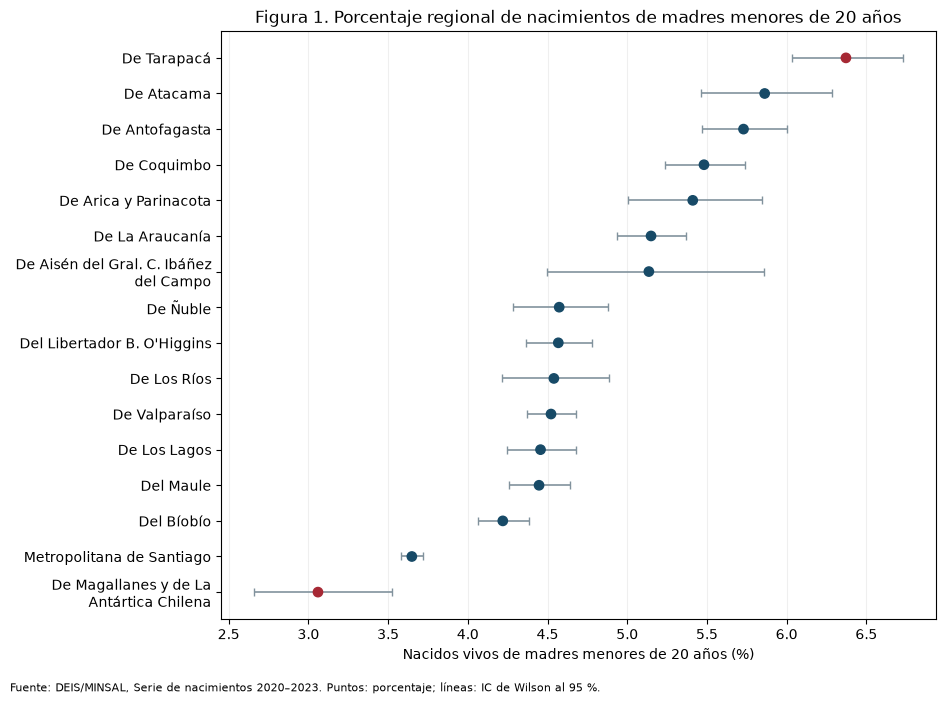

In [5]:
from textwrap import fill
azul, rojo, gris = "#174A67", "#A62834", "#81929D"
fig, ax = plt.subplots(figsize=(9.5, 7.0))
y = np.arange(len(regional))
colores = [rojo if i in (0, len(regional)-1) else azul for i in range(len(regional))]
ax.errorbar(regional.porcentaje, y,
            xerr=[regional.porcentaje-regional.ic_inf,
                  regional.ic_sup-regional.porcentaje],
            fmt="none", ecolor=gris, capsize=3, linewidth=1.2)
ax.scatter(regional.porcentaje, y, c=colores, s=45, zorder=3)
ax.set_yticks(y, [fill(x, 28) for x in regional.GLOSA_REGION_RESIDENCIA])
ax.set_xlabel("Nacidos vivos de madres menores de 20 años (%)")
ax.set_title("Figura 1. Porcentaje regional de nacimientos de madres menores de 20 años")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
fig.text(0.01, 0.005, "Fuente: DEIS/MINSAL, Serie de nacimientos 2020–2023. "
         "Puntos: porcentaje; líneas: IC de Wilson al 95 %.", fontsize=8)
fig.tight_layout(rect=(0, 0.025, 1, 1))
fig.savefig(FIGURAS / "figura_1_madres_menores_20_region.png", dpi=200, bbox_inches="tight")
plt.show()

## V. F4 · Nacimientos por mes y variación interanual

El archivo registra mes y año, **no el día de cada nacimiento**. Por eso el promedio diario es el total del mes dividido por sus días calendario. Para cada mes del año se suman los cuatro totales y se divide por el total de días correspondientes de 2020–2023. El año bisiesto se incorpora mediante el calendario. El mapa de calor complementario permite comprobar si el patrón mensual se repite.

In [6]:
calendario = pd.DataFrame(
    [(a, m, calendar.monthrange(a, m)[1])
     for a in range(2020, 2024) for m in range(1, 13)],
    columns=["ANO_NAC", "MES_NAC", "dias"]
)
conteos = (
    datos.groupby(["ANO_NAC", "MES_NAC"], observed=True)
    .size().rename("nacimientos").reset_index()
)
mensual_anual = calendario.merge(conteos, on=["ANO_NAC", "MES_NAC"],
                                  how="left", validate="one_to_one")
mensual_anual["nacimientos"] = mensual_anual.nacimientos.fillna(0).astype(int)
mensual_anual["por_dia"] = mensual_anual.nacimientos / mensual_anual.dias
mensual = (
    mensual_anual.groupby("MES_NAC", observed=True)
    .agg(nacimientos=("nacimientos", "sum"), dias=("dias", "sum"))
    .reset_index()
)
mensual["por_dia"] = mensual.nacimientos / mensual.dias
anual = (
    mensual_anual.groupby("ANO_NAC", observed=True)
    .agg(nacimientos=("nacimientos", "sum"), dias=("dias", "sum"))
    .reset_index()
)
anual["por_dia"] = anual.nacimientos / anual.dias
anual["cambio_pct_vs_previo"] = anual.por_dia.pct_change() * 100
assert calendario.dias.sum() == 1461
assert calendar.monthrange(2020, 2)[1] == 29
assert calendar.monthrange(2021, 2)[1] == 28
assert mensual.nacimientos.sum() == anual.nacimientos.sum() == len(datos)
meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
         "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
display(mensual.assign(mes=meses)[["mes", "nacimientos", "dias", "por_dia"]].round(2))
display(anual.round(2))
max_mes = mensual.loc[mensual.por_dia.idxmax()]
min_mes = mensual.loc[mensual.por_dia.idxmin()]
print(f"Extremos del promedio 2020–2023: {meses[int(max_mes.MES_NAC)-1]} "
      f"{max_mes.por_dia:.1f} y {meses[int(min_mes.MES_NAC)-1]} "
      f"{min_mes.por_dia:.1f} nacimientos por día.")

,mes,nacimientos,dias,por_dia
0,Ene,64798,124,522.56
1,Feb,58179,113,514.86
2,Mar,64713,124,521.88
3,Abr,61473,120,512.28
4,May,62574,124,504.63
5,Jun,61212,120,510.10
6,Jul,61232,124,493.81
7,Ago,60305,124,486.33
8,Sep,61354,120,511.28
9,Oct,60435,124,487.38


,ANO_NAC,nacimientos,dias,por_dia,cambio_pct_vs_previo
0,2020,194978,366,532.73,NaN
1,2021,177273,365,485.68,-8.83
2,2022,189303,365,518.64,6.79
3,2023,174057,365,476.87,-8.05


Extremos del promedio 2020–2023: Ene 522.6 y Dic 486.2 nacimientos por día.


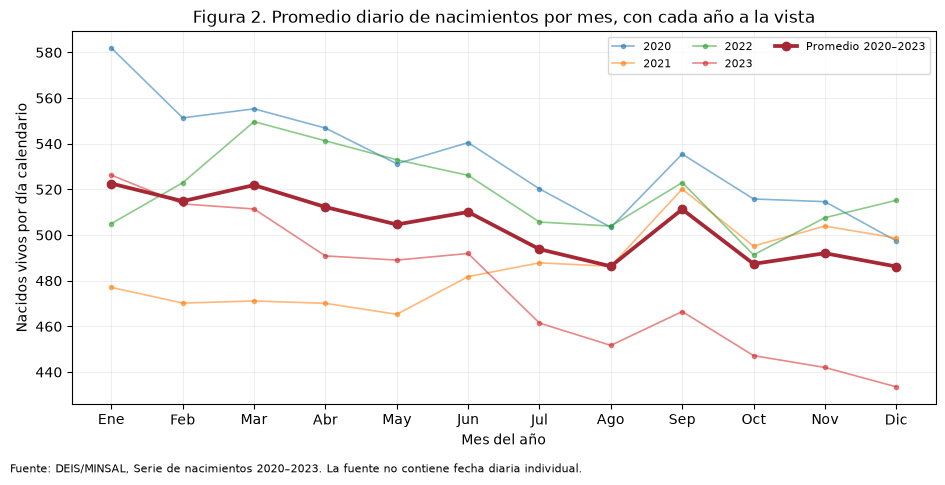

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
for ano, sub in mensual_anual.groupby("ANO_NAC"):
    ax.plot(sub.MES_NAC, sub.por_dia, linewidth=1.2, alpha=0.55,
            marker=".", label=str(ano))
ax.plot(mensual.MES_NAC, mensual.por_dia, color=rojo, linewidth=2.7,
        marker="o", label="Promedio 2020–2023")
ax.set_xticks(range(1, 13), meses)
ax.set_ylabel("Nacidos vivos por día calendario")
ax.set_xlabel("Mes del año")
ax.set_title("Figura 2. Promedio diario de nacimientos por mes, con cada año a la vista")
ax.grid(alpha=0.2)
ax.legend(ncol=3, fontsize=8)
fig.text(0.01, 0.005, "Fuente: DEIS/MINSAL, Serie de nacimientos 2020–2023. "
         "La fuente no contiene fecha diaria individual.", fontsize=8)
fig.tight_layout(rect=(0, 0.025, 1, 1))
fig.savefig(FIGURAS / "figura_2_promedio_diario_mes.png", dpi=200, bbox_inches="tight")
plt.show()

### Vista complementaria: estabilidad por año

Cada celda muestra nacimientos por día calendario en ese mes y año. El gráfico anual y esta matriz describen cambios durante 2020–2023; **no atribuyen esos cambios a la pandemia** porque falta una referencia anterior a 2020 y otros factores pueden intervenir.

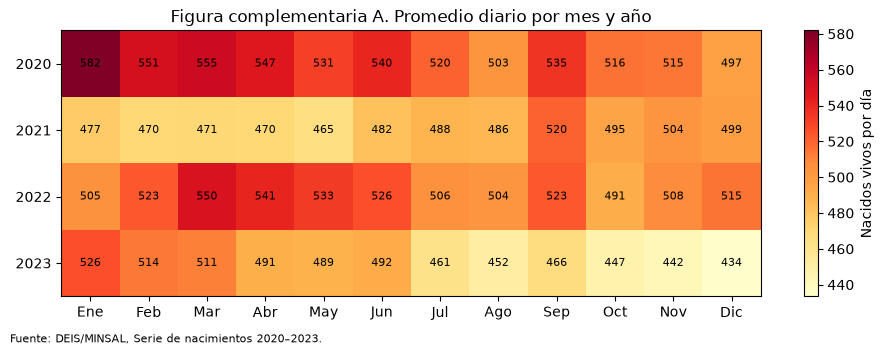

In [8]:
matriz = mensual_anual.pivot(index="ANO_NAC", columns="MES_NAC", values="por_dia")
fig, ax = plt.subplots(figsize=(9.5, 3.5))
imagen = ax.imshow(matriz.to_numpy(), cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(12), meses)
ax.set_yticks(range(4), matriz.index.astype(str))
for i in range(4):
    for j in range(12):
        ax.text(j, i, f"{matriz.iloc[i,j]:.0f}", ha="center", va="center",
                color="black", fontsize=8)
ax.set_title("Figura complementaria A. Promedio diario por mes y año")
fig.colorbar(imagen, ax=ax, label="Nacidos vivos por día")
fig.text(0.01, 0.005, "Fuente: DEIS/MINSAL, Serie de nacimientos 2020–2023.", fontsize=8)
fig.tight_layout(rect=(0, 0.025, 1, 1))
fig.savefig(FIGURAS / "complementaria_a_mes_ano.png", dpi=200, bbox_inches="tight")
plt.show()

## VI. F4 · Talla media por región y sensibilidad de la imputación

La figura principal usa `talla_analisis_cm`, que incorpora la **mediana regional** elegida en F2. Se muestran centímetros e intervalos de media al 95 % calculados con la variación de esa serie. Estos intervalos no incluyen la incertidumbre sobre las tallas ausentes: la imputación no equivale a nuevas mediciones. Por eso la prueba de diferencias entre regiones se ejecuta **solo con tallas observadas** y la tabla de sensibilidad comprueba cuánto cambian las medias al excluir las 597 imputaciones.

In [9]:
claves_region = ["REGION_RESIDENCIA", "GLOSA_REGION_RESIDENCIA"]
talla = (
    datos.groupby(claves_region, observed=True)
    .agg(n=("talla_analisis_cm", "count"),
         media_cm=("talla_analisis_cm", "mean"),
         desv_cm=("talla_analisis_cm", "std"),
         imputadas=("talla_imputada", "sum"))
    .reset_index()
)
observada = (
    datos.groupby(claves_region, observed=True)
    .agg(n_observadas=("talla_observada_cm", "count"),
         media_observada_cm=("talla_observada_cm", "mean"))
    .reset_index()
)
talla = talla.merge(observada, on=claves_region, validate="one_to_one")
talla["se_cm"] = talla.desv_cm / np.sqrt(talla.n)
critico = stats.t.ppf(0.975, talla.n-1)
talla["ic_inf_cm"] = talla.media_cm - critico*talla.se_cm
talla["ic_sup_cm"] = talla.media_cm + critico*talla.se_cm
talla["cambio_imputacion_cm"] = talla.media_cm - talla.media_observada_cm
talla = talla.sort_values(["media_cm", "REGION_RESIDENCIA"]).reset_index(drop=True)
display(talla[["GLOSA_REGION_RESIDENCIA", "n", "imputadas", "media_cm",
               "ic_inf_cm", "ic_sup_cm", "media_observada_cm",
               "cambio_imputacion_cm"]].round(4))
min_talla, max_talla = talla.iloc[0], talla.iloc[-1]
print(f"Extremos: {max_talla.GLOSA_REGION_RESIDENCIA} "
      f"{max_talla.media_cm:.2f} cm y {min_talla.GLOSA_REGION_RESIDENCIA} "
      f"{min_talla.media_cm:.2f} cm.")
print("Mayor cambio absoluto por imputación:",
      f"{talla.cambio_imputacion_cm.abs().max():.4f} cm.")
observada_ordenada = talla.sort_values(["media_observada_cm", "REGION_RESIDENCIA"])
extremos_estables = (
    observada_ordenada.iloc[0].REGION_RESIDENCIA == min_talla.REGION_RESIDENCIA
    and observada_ordenada.iloc[-1].REGION_RESIDENCIA == max_talla.REGION_RESIDENCIA
)
print("Los extremos se conservan al excluir tallas imputadas:", extremos_estables)

,GLOSA_REGION_RESIDENCIA,n,imputadas,media_cm,ic_inf_cm,ic_sup_cm,media_observada_cm,cambio_imputacion_cm
0,De Antofagasta,28659,28,48.6165,48.5896,48.6433,48.6161,0.0004
1,Del Libertador B. O'Higgins,38663,24,48.6806,48.6576,48.7035,48.6804,0.0002
2,De Magallanes y de La Antártica Chilena,6111,12,48.7223,48.6625,48.7821,48.7218,0.0005
3,Del Maule,44976,27,48.7515,48.7294,48.7736,48.7514,0.0001
4,De Valparaíso,70037,46,48.7795,48.7616,48.7974,48.7794,0.0001
5,De La Araucanía,40335,29,48.8526,48.8287,48.8764,48.8525,0.0001
6,De Coquimbo,31196,41,48.8540,48.8278,48.8803,48.8538,0.0002
7,Metropolitana de Santiago,299408,162,48.8927,48.8841,48.9014,48.8927,0.0001
8,De Ñuble,18936,17,48.9363,48.9019,48.9707,48.9363,0.0001
9,De Aisén del Gral. C. Ibáñez del Campo,4050,16,48.9731,48.9005,49.0457,48.9730,0.0001


Extremos: De Arica y Parinacota 49.33 cm y De Antofagasta 48.62 cm.
Mayor cambio absoluto por imputación: 0.0008 cm.
Los extremos se conservan al excluir tallas imputadas: True


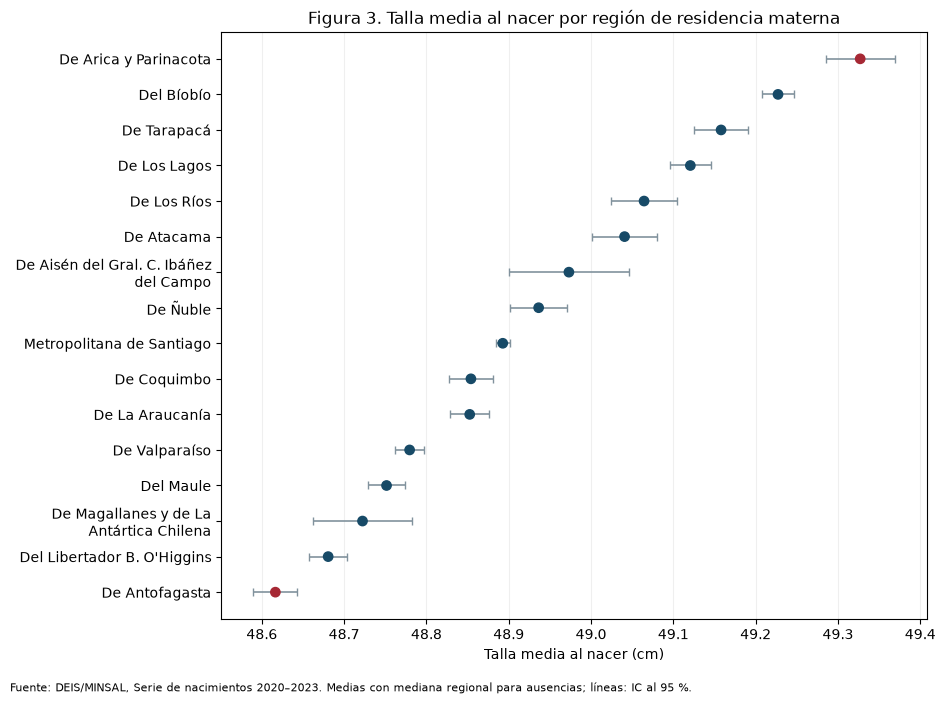

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 7.0))
y = np.arange(len(talla))
colores = [rojo if i in (0, len(talla)-1) else azul for i in range(len(talla))]
ax.errorbar(talla.media_cm, y,
            xerr=[talla.media_cm-talla.ic_inf_cm,
                  talla.ic_sup_cm-talla.media_cm],
            fmt="none", ecolor=gris, capsize=3, linewidth=1.2)
ax.scatter(talla.media_cm, y, c=colores, s=45, zorder=3)
ax.set_yticks(y, [fill(x, 28) for x in talla.GLOSA_REGION_RESIDENCIA])
ax.set_xlabel("Talla media al nacer (cm)")
ax.set_title("Figura 3. Talla media al nacer por región de residencia materna")
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)
fig.text(0.01, 0.005, "Fuente: DEIS/MINSAL, Serie de nacimientos 2020–2023. "
         "Medias con mediana regional para ausencias; líneas: IC al 95 %.", fontsize=8)
fig.tight_layout(rect=(0, 0.025, 1, 1))
fig.savefig(FIGURAS / "figura_3_talla_media_region.png", dpi=200, bbox_inches="tight")
plt.show()

## VII. Comparaciones globales: preguntas distintas, pruebas distintas

Las tres pruebas **exploratorias** comparan todos los grupos antes de mirar pares extremos:

* **Región × edad materna:** chi-cuadrado sobre la tabla 16 × 2; V de Cramér indica el tamaño de la asociación.
* **Mes del calendario:** chi-cuadrado entre los 12 conteos observados y los esperados si hubiera una tasa diaria constante, considerando que los meses tienen distinta duración. Al agrupar cuatro años con niveles diferentes de nacimientos, el resultado puede reflejar tendencia anual además del mes. No demuestra una causa estacional.
* **Talla observada entre regiones:** ANOVA de Welch, que permite dispersiones desiguales. La prueba excluye los valores imputados.

Se informan p-values junto a diferencias y tamaños, no como sustitutos de ellos. Al tratarse de todos los registros disponibles para 2020–2023, las diferencias observadas de ese período son descriptivas; los p-values dependen de supuestos sobre un proceso que podría repetirse y sobre independencia entre observaciones. Dos nacidos vivos de un mismo parto podrían compartir características; esa independencia no está garantizada. Los extremos elegidos después de ver la tabla **no son hipótesis predefinidas**. No se interpretará el simple solapamiento de intervalos como prueba de igualdad o diferencia.

In [11]:
def formato_p(p):
    return "< 1e-300" if p == 0 else f"{p:.3g}"

tabla_reg = regional[["menores_20", "nacimientos"]].copy()
contingencia = np.column_stack([
    tabla_reg.menores_20.to_numpy(),
    (tabla_reg.nacimientos-tabla_reg.menores_20).to_numpy(),
])
chi_region = stats.chi2_contingency(contingencia)
v_cramer = np.sqrt(chi_region.statistic / contingencia.sum())

esperados_mes = mensual.nacimientos.sum() * mensual.dias / mensual.dias.sum()
chi_mes = stats.chisquare(mensual.nacimientos.to_numpy(), f_exp=esperados_mes.to_numpy())

grupos_talla = [
    sub.talla_observada_cm.dropna().to_numpy()
    for _, sub in datos.groupby("REGION_RESIDENCIA", observed=True)
]
welch = stats.f_oneway(*grupos_talla, equal_var=False)

pruebas = pd.DataFrame([
    {"pregunta": "Porcentaje regional de madres <20", "prueba": "Chi-cuadrado (16 × 2)",
     "estadístico": chi_region.statistic, "p": chi_region.pvalue,
     "dato adicional": f"V de Cramér = {v_cramer:.3f}"},
    {"pregunta": "Nacimientos por mes", "prueba": "Chi-cuadrado con exposición de días",
     "estadístico": chi_mes.statistic, "p": chi_mes.pvalue,
     "dato adicional": "Referencia: tasa diaria constante"},
    {"pregunta": "Talla observada por región", "prueba": "ANOVA de Welch",
     "estadístico": welch.statistic, "p": welch.pvalue,
     "dato adicional": "Sin las 597 tallas imputadas"},
])
pruebas["p_mostrado"] = pruebas.p.map(formato_p)
display(pruebas.drop(columns="p").round({"estadístico": 2}))

,pregunta,prueba,estadístico,dato adicional,p_mostrado
0,Porcentaje regional de madres <20,Chi-cuadrado (16 × 2),977.26,V de Cramér = 0.036,1.01e-198
1,Nacimientos por mes,Chi-cuadrado con exposición de días,509.73,Referencia: tasa diaria constante,2.69e-102
2,Talla observada por región,ANOVA de Welch,223.55,Sin las 597 tallas imputadas,< 1e-300


## VIII. Resultados, discusión y conclusiones

La tabla siguiente responde las tres preguntas con cifras calculadas durante esta ejecución. Una diferencia global detectada estadísticamente no implica que todas las regiones difieran entre sí, ni que la diferencia sea grande o causal. En el informe se discutirán también la amplitud de los intervalos, los tamaños de los grupos y la estabilidad por año.

In [12]:
respuestas = pd.DataFrame([
    {"pregunta": 1, "mayor": mayor_region.GLOSA_REGION_RESIDENCIA,
     "valor_mayor": f"{mayor_region.porcentaje:.2f} %",
     "menor": menor_region.GLOSA_REGION_RESIDENCIA,
     "valor_menor": f"{menor_region.porcentaje:.2f} %",
     "brecha": f"{mayor_region.porcentaje-menor_region.porcentaje:.2f} puntos porcentuales"},
    {"pregunta": 2, "mayor": meses[int(max_mes.MES_NAC)-1],
     "valor_mayor": f"{max_mes.por_dia:.1f} por día",
     "menor": meses[int(min_mes.MES_NAC)-1],
     "valor_menor": f"{min_mes.por_dia:.1f} por día",
     "brecha": f"{max_mes.por_dia-min_mes.por_dia:.1f} por día"},
    {"pregunta": 3, "mayor": max_talla.GLOSA_REGION_RESIDENCIA,
     "valor_mayor": f"{max_talla.media_cm:.2f} cm",
     "menor": min_talla.GLOSA_REGION_RESIDENCIA,
     "valor_menor": f"{min_talla.media_cm:.2f} cm",
     "brecha": f"{max_talla.media_cm-min_talla.media_cm:.2f} cm"},
])
display(respuestas)
print("Variación anual: ver tabla y matriz de la sección V; no permite atribución causal.")
print("Sensibilidad de talla: ver diferencia entre media imputada y observada en la sección VI.")

,pregunta,mayor,valor_mayor,menor,valor_menor,brecha
0,1,De Tarapacá,6.37 %,De Magallanes y de La Antártica Chilena,3.06 %,3.31 puntos porcentuales
1,2,Ene,522.6 por día,Dic,486.2 por día,36.3 por día
2,3,De Arica y Parinacota,49.33 cm,De Antofagasta,48.62 cm,0.71 cm


Variación anual: ver tabla y matriz de la sección V; no permite atribución causal.
Sensibilidad de talla: ver diferencia entre media imputada y observada en la sección VI.


### Interpretación y límites

Las diferencias regionales se refieren a la **región de residencia materna**, no necesariamente a la región donde ocurrió el parto. El porcentaje de menores de 20 años usa nacidos vivos como denominador; no mide riesgo de embarazo. Las tasas mensuales se normalizan por días de calendario, pero la fuente preparada no permite estudiar días de la semana. El cambio entre 2020 y 2023 se describe sin atribuirlo a la pandemia. La talla de análisis incorpora 597 imputaciones acordadas por el grupo; su sensibilidad se documenta arriba. Incluso con p-values bajos, el tamaño de la brecha y el contexto determinan la relevancia práctica.

**Conclusión técnica:** F4 responde las preguntas formuladas en F1 con la salida validada de F2 y reutiliza la arquitectura y las mediciones de F3. La mejora metodológica principal es conectar cada conclusión con una tabla, una figura, su denominador y una limitación explícita.

## IX. Trazabilidad de mejoras F1–F4

Los vínculos apuntan a cambios ya fusionados; este notebook aún está en una rama local y no se le asigna un commit ficticio. El informe final deberá enlazar el commit real de F4 una vez que el grupo lo revise.

In [13]:
trazabilidad = pd.DataFrame([
    {"observación o necesidad": "Datos y decisiones de F2 debían ser trazables",
     "acción comprobable": "Metadatos, marcas de talla y calendario conservados",
     "evidencia": "docs/f2/metadatos.json; F2/F2_Preparacion.ipynb"},
    {"observación o necesidad": "F3 debía comparar eficiencia y modularizar",
     "acción comprobable": "Clase, estrategias y mediciones verificadas aquí",
     "evidencia": "F3/resultados/mediciones.json; PR #7"},
    {"observación o necesidad": "Repositorio contenía archivos residuales",
     "acción comprobable": "Limpieza y aclaración de entregables F3",
     "evidencia": "https://github.com/jorgealtamiranonavarrete-art/proyecto-grupo2/pull/8"},
    {"observación o necesidad": "F4 debe responder objetivos con figuras",
     "acción comprobable": "Tres figuras principales, pruebas y sensibilidad",
     "evidencia": "Este cuaderno local; commit de F4 tras la revisión del grupo"},
])
display(trazabilidad)

,observación o necesidad,acción comprobable,evidencia
0,Datos y decisiones de F2 debían ser trazables,"Metadatos, marcas de talla y calendario conser...",docs/f2/metadatos.json; F2/F2_Preparacion.ipynb
1,F3 debía comparar eficiencia y modularizar,"Clase, estrategias y mediciones verificadas aquí",F3/resultados/mediciones.json; PR #7
2,Repositorio contenía archivos residuales,Limpieza y aclaración de entregables F3,https://github.com/jorgealtamiranonavarrete-ar...
3,F4 debe responder objetivos con figuras,"Tres figuras principales, pruebas y sensibilidad",Este cuaderno local; commit de F4 tras la revi...


## X. Verificación final y fuentes

Se comprueba que las tres figuras principales existen, las agregaciones conservan todas las filas y los resultados enlazan con F2 y F3. Las figuras complementarias quedan en `F4/figuras/`.

In [14]:
controles = pd.DataFrame([
    {"verificación": "Filas conservadas F2–F4", "ok": len(datos) == meta_f3["entrada"]["filas"]},
    {"verificación": "Indicador igual a la clase F3", "ok": indicador_f3.equals(control)},
    {"verificación": "Mediana regional igual a F2", "ok": bool(np.allclose(talla_reconstruida, datos.talla_analisis_cm))},
    {"verificación": "Todos los meses y 1461 días", "ok": len(mensual_anual) == 48 and calendario.dias.sum() == 1461},
    {"verificación": "Tres figuras principales exportadas",
     "ok": all((FIGURAS / nombre).is_file() for nombre in (
         "figura_1_madres_menores_20_region.png",
         "figura_2_promedio_diario_mes.png",
         "figura_3_talla_media_region.png"))},
    {"verificación": "Tres respuestas calculadas", "ok": len(respuestas) == 3},
    {"verificación": "Sensibilidad de talla calculada", "ok": talla.cambio_imputacion_cm.notna().all()},
    {"verificación": "Extremos de talla estables sin imputación", "ok": extremos_estables},
])
display(controles)
assert controles.ok.all(), "Hay verificaciones pendientes."
print("Cuaderno F4 verificado: todas las comprobaciones aprobaron.")

,verificación,ok
0,Filas conservadas F2–F4,True
1,Indicador igual a la clase F3,True
2,Mediana regional igual a F2,True
3,Todos los meses y 1461 días,True
4,Tres figuras principales exportadas,True
5,Tres respuestas calculadas,True
6,Sensibilidad de talla calculada,True
7,Extremos de talla estables sin imputación,True


Cuaderno F4 verificado: todas las comprobaciones aprobaron.


## XI. Mapas interactivos complementarios

Los dos mapas siguientes permiten consultar las 16 regiones mediante cursor, teclado o lista, y acercar o desplazar la vista. Reutilizan **exactamente** los indicadores y denominadores de las secciones IV y VI. Son un complemento exploratorio: las tres figuras principales siguen siendo las comparaciones más legibles. La geometría se atribuye a [geoBoundaries gbOpen CHL ADM1](https://www.geoboundaries.org/api/current/gbOpen/CHL/ADM1/) (origen BCN/OCHA ROLAC), se simplificó para un HTML local y omite islas oceánicas lejanas de Valparaíso en la vista principal. El color no debe interpretarse como área, distancia o causa.

In [15]:
from IPython.display import HTML
sys.path.insert(0, str(RAIZ / "F4/src"))
from f4_mapas import generar_mapa

GEOMETRIA = RAIZ / "F4/mapas/regiones_chile_simplificado.geojson"
MAPAS = RAIZ / "F4/mapas"
def miles(n):
    return f"{int(n):,}".replace(",", ".")
registros_edad = [
    {"region_code": int(r.REGION_RESIDENCIA),
     "name": r.GLOSA_REGION_RESIDENCIA,
     "value": float(r.porcentaje),
     "n": int(r.nacimientos),
     "detail": (f"Nacidos vivos de madres menores de 20 años: {miles(r.menores_20)}. "
                f"Intervalo de Wilson al 95 %: {r.ic_inf:.2f}–{r.ic_sup:.2f} %." )}
    for r in regional.itertuples(index=False)
]
registros_talla = [
    {"region_code": int(r.REGION_RESIDENCIA),
     "name": r.GLOSA_REGION_RESIDENCIA,
     "value": float(r.media_cm),
     "n": int(r.n),
     "detail": (f"Tallas con mediana regional: {miles(r.imputadas)} de {miles(r.n)}. "
                f"Media solo observada: {r.media_observada_cm:.2f} cm. "
                f"Intervalo de la media de análisis al 95 %: "
                f"{r.ic_inf_cm:.2f}–{r.ic_sup_cm:.2f} cm.")}
    for r in talla.itertuples(index=False)
]

# Caso límite: una región faltante debe detener la generación.
try:
    generar_mapa(GEOMETRIA, registros_edad[:-1], MAPAS / "no_generar.html",
                 title="Control", unit="%", explanation="Control",
                 low_color="#fff4e6", high_color="#a62834")
except ValueError:
    pass
else:
    raise AssertionError("Un mapa incompleto debe rechazarse.")

mapa_edad = generar_mapa(
    GEOMETRIA, registros_edad, MAPAS / "mapa_madres_menores_20.html",
    title="Nacimientos de madres menores de 20 años por región",
    unit="%", low_color="#fff2dc", high_color="#a62834",
    explanation="Porcentaje de nacidos vivos de madres menores de 20 años en cada región de residencia materna. Denominador: todos los nacidos vivos de esa región; no mide riesgo de embarazo."
)
mapa_talla = generar_mapa(
    GEOMETRIA, registros_talla, MAPAS / "mapa_talla_media.html",
    title="Talla media al nacer por región",
    unit="cm", low_color="#e7f3f8", high_color="#174a67",
    explanation="Media regional de talla al nacer en centímetros, con mediana regional para las 597 tallas ausentes. La prueba estadística del notebook usa solo tallas observadas."
)
assert mapa_edad.is_file() and mapa_talla.is_file()
print("Mapas interactivos exportados:", mapa_edad, mapa_talla, sep="\n")
display(HTML('<p><a href="mapas/mapa_madres_menores_20.html">Abrir mapa de madres menores de 20 años</a><br>'
             '<a href="mapas/mapa_talla_media.html">Abrir mapa de talla media</a></p>'))

Mapas interactivos exportados:
D:\Magister UNAB\Curso 01\C01Week01\Evaluaciones\proyecto-grupo2\F4\mapas\mapa_madres_menores_20.html
D:\Magister UNAB\Curso 01\C01Week01\Evaluaciones\proyecto-grupo2\F4\mapas\mapa_talla_media.html


**Fuentes técnicas y de datos para este cuaderno:** [DEIS/MINSAL, datos abiertos](https://deis.minsal.cl/#datosabiertos); [material docente de Semana 3](https://github.com/magistercienciadatos/Material_Didactico_Semana3); [SciPy, prueba chi-cuadrado](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html); [SciPy, ANOVA de Welch](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html); [documentación de pandas, agrupaciones](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html); [geoBoundaries, límites regionales](https://www.geoboundaries.org/api/current/gbOpen/CHL/ADM1/). Las referencias completas en APA 7 corresponden al informe final.